# 파일 업로드 후 히스토그램 확인


📂 'normal_msg.csv' 파일을 읽는 중... (약 1~2분 소요될 수 있음)
✅ 파일 로드 완료!
   - 총 데이터 행 수: 52,588,032 개
📊 추출된 비트(변화) 개수: 2,041 개
   - 평균 비트 길이: 997052.18 ns


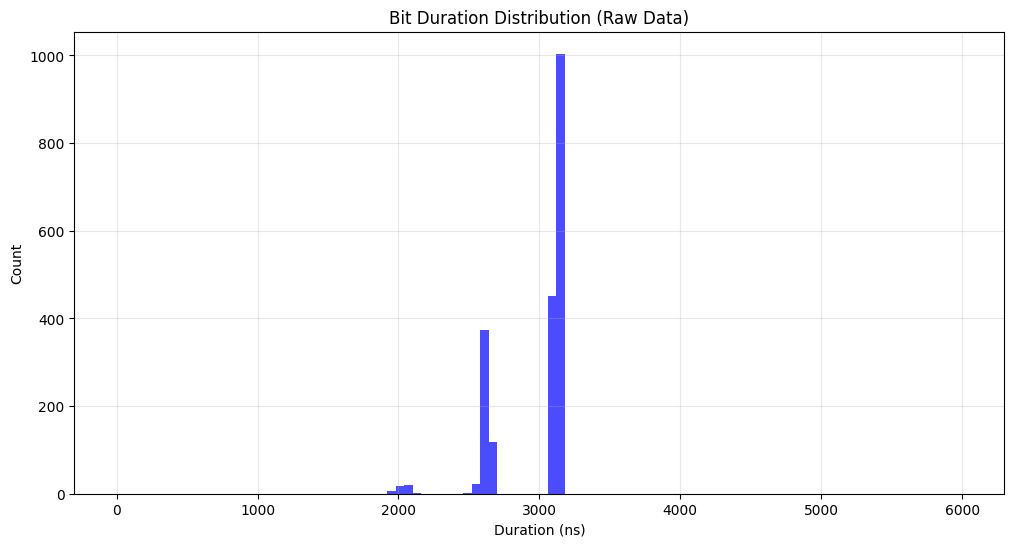

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 파일 읽기 (용량이 커서 시간이 좀 걸립니다)
filename = 'normal_msg.csv'
print(f"📂 '{filename}' 파일을 읽는 중... (약 1~2분 소요될 수 있음)")

# 1.3GB 파일을 읽습니다.
df = pd.read_csv(filename)

# 공백 제거 및 컬럼 확인
df.columns = df.columns.str.strip()
print("✅ 파일 로드 완료!")
print(f"   - 총 데이터 행 수: {len(df):,} 개")

# 2. 비트 길이 계산 (Raw 데이터 처리)
# Dedup이 꺼져있어도(0,0,0,1,1,1...), 값이 변하는 순간(Edge)을 찾으면 됩니다.
timestamps = df.iloc[:, 0].values
signals = df.iloc[:, 1].values

# 값이 변하는 지점(Edge) 찾기
edges = np.where(np.diff(signals) != 0)[0]

# 시간 차이 계산 (다음 엣지 - 현재 엣지 = 비트 유지 시간)
# timestamps 배열에서 해당 인덱스의 시간을 가져와 뺍니다.
durations = timestamps[edges[1:]] - timestamps[edges[:-1]]

print(f"📊 추출된 비트(변화) 개수: {len(durations):,} 개")

# 3. 히스토그램 확인 (필터링 기준 잡기용)
if len(durations) > 0:
    print(f"   - 평균 비트 길이: {np.mean(durations):.2f} ns")

    plt.figure(figsize=(12, 6))
    # 0 ~ 6000ns 사이의 분포만 봅니다.
    plt.hist(durations, bins=100, range=(0, 6000), color='blue', alpha=0.7)
    plt.title("Bit Duration Distribution (Raw Data)")
    plt.xlabel("Duration (ns)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("❌ 신호 변화가 감지되지 않았습니다.")

# 학습 및 모델 파일 생성
contamination=0.1인 3번 모델이 제일 정확

특징 추출 중...
▶ 필터링 후 유효 비트 개수: 2,018 개
✅ 최종 학습 데이터셋(X_train) 크기: (1998, 2)


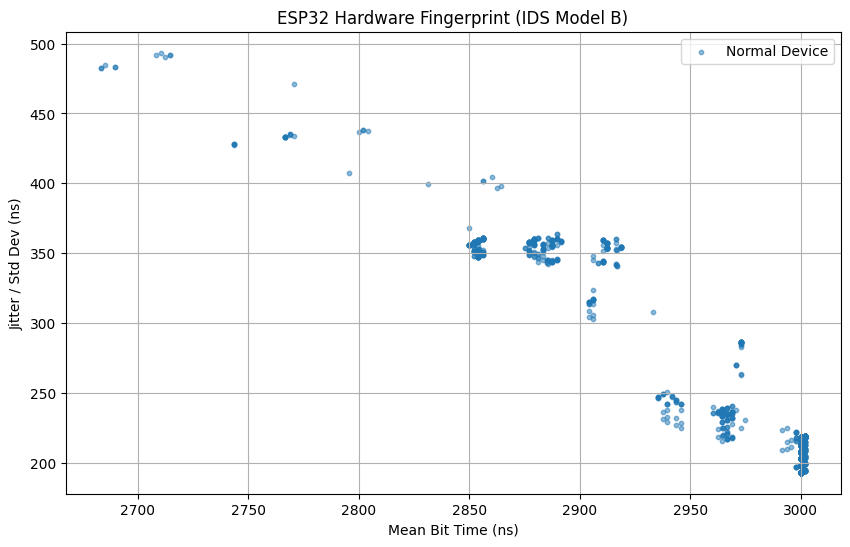


[IDS B 학습 시작...]
🎉 학습 완료!
💾 모델 저장 완료: ids_model_b1-3.pkl


In [16]:
from sklearn.ensemble import IsolationForest
import joblib

# --- 설정 ---
# 그래프를 보니 2000~3200ns에 몰려있으므로 범위를 넉넉하게 잡습니다.
MIN_BIT_TIME = 1500
MAX_BIT_TIME = 4000
WINDOW_SIZE = 20     # 데이터가 2000개니까, 윈도우를 50->20으로 줄여서 샘플을 더 많이 만듭시다.

def create_features(durations):
    valid_bits = []

    # 1. 유효 범위(1.5us ~ 4us)에 있는 비트만 남기기 (노이즈 & 휴식시간 제거)
    valid_bits = durations[(durations > MIN_BIT_TIME) & (durations < MAX_BIT_TIME)]

    print(f"▶ 필터링 후 유효 비트 개수: {len(valid_bits):,} 개")

    if len(valid_bits) < WINDOW_SIZE:
        print("⚠️ 데이터가 너무 적습니다.")
        return np.array([])

    # 2. 특징 추출 (Sliding Window -> Mean, Std)
    features = []
    # step을 1로 해서 데이터를 최대한 많이 확보 (Overlap)
    for i in range(0, len(valid_bits) - WINDOW_SIZE, 1):
        window = valid_bits[i : i + WINDOW_SIZE]
        mean_val = np.mean(window) # 평균 (Clock Skew)
        std_val = np.std(window)   # 표준편차 (Jitter)
        features.append([mean_val, std_val])

    return np.array(features)

# --- 실행 ---
print("특징 추출 중...")
# (위에서 이미 로드한 'durations' 변수를 그대로 씁니다)
X_train = create_features(durations)

if len(X_train) > 0:
    print(f"✅ 최종 학습 데이터셋(X_train) 크기: {X_train.shape}")

    # 데이터 분포 시각화 (지문 확인)
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], s=10, alpha=0.5, label='Normal Device')
    plt.title('ESP32 Hardware Fingerprint (IDS Model B)')
    plt.xlabel('Mean Bit Time (ns)')
    plt.ylabel('Jitter / Std Dev (ns)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- 모델 학습 ---
    print("\n[IDS B 학습 시작...]")
    model = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1)
    model.fit(X_train)
    model2 = IsolationForest(n_estimators=100, contamination=0.001, random_state=42, n_jobs=-1)
    model2.fit(X_train)
    model3 = IsolationForest(n_estimators=100, contamination=0.1, random_state=42, n_jobs=-1)
    model3.fit(X_train)
    print("🎉 학습 완료!")

    # 모델 저장
    joblib.dump(model, 'ids_model_b.pkl')
    joblib.dump(model2, 'ids_model_b2.pkl')
    joblib.dump(model3, 'ids_model_b3.pkl')
    print("💾 모델 저장 완료: ids_model_b1-3.pkl")

else:
    print("❌ 학습할 데이터가 없습니다.")

.csv가 너무 무거워서 매번 업로드하기 힘들면 해당 코드 돌려서 특징만 추출한 가벼운 .npy 파일 만들기

In [4]:
import pandas as pd
import numpy as np

# --- 1. 설정 (학습 때 썼던 것과 똑같이!) ---
FILENAME = 'normal_msg.csv'  # 무거운 원본 파일
SAVE_NAME = 'features_normal.npy'  # 저장할 가벼운 특징 파일 이름

MIN_BIT_TIME = 1500
MAX_BIT_TIME = 4000
WINDOW_SIZE = 20

# --- 2. 특징 추출 함수 ---
def extract_and_save_features(filename, save_name):
    print(f"📂 무거운 파일 '{filename}' 읽는 중... (기다려주세요)")
    try:
        df = pd.read_csv(filename)
        df.columns = df.columns.str.strip()

        # 비트 길이 계산 (Diff)
        timestamps = df.iloc[:, 0].values
        signals = df.iloc[:, 1].values
        edges = np.where(np.diff(signals) != 0)[0]
        durations = timestamps[edges[1:]] - timestamps[edges[:-1]]

        # 필터링
        valid_bits = durations[(durations > MIN_BIT_TIME) & (durations < MAX_BIT_TIME)]
        print(f"   - 추출된 유효 비트 수: {len(valid_bits)}개")

        if len(valid_bits) < WINDOW_SIZE:
            print("❌ 데이터가 너무 적어 저장하지 않았습니다.")
            return

        # 특징 추출 (Sliding Window)
        features = []
        for i in range(0, len(valid_bits) - WINDOW_SIZE, 1):
            window = valid_bits[i : i + WINDOW_SIZE]
            features.append([np.mean(window), np.std(window)])

        X_data = np.array(features)

        # --- 핵심: 파일로 저장 (.npy) ---
        np.save(save_name, X_data)

        print(f"\n✅ 저장 완료!")
        print(f"   - 파일명: {save_name}")
        print(f"   - 데이터 크기: {X_data.shape}")
        print("👉 왼쪽 파일 탭에서 이 파일을 우클릭 -> 다운로드해서 PC에 보관하세요!")

    except Exception as e:
        print(f"에러 발생: {e}")

# --- 실행 ---
extract_and_save_features(FILENAME, SAVE_NAME)

📂 무거운 파일 'normal_msg.csv' 읽는 중... (기다려주세요)
   - 추출된 유효 비트 수: 2018개

✅ 저장 완료!
   - 파일명: features_normal.npy
   - 데이터 크기: (1998, 2)
👉 왼쪽 파일 탭에서 이 파일을 우클릭 -> 다운로드해서 PC에 보관하세요!
